# 🛒 Blinkit Sales & Profitability Analysis

## Project Overview
This project analyzes Blinkit's sales performance, profitability, customer purchasing behavior, discounts, delivery efficiency, and product trends using Python-based Exploratory Data Analysis (EDA).

## Business Objectives
- Identify top-performing categories and brands
- Analyze revenue and profit drivers
- Evaluate discount effectiveness
- Monitor city-wise demand
- Track monthly revenue trends
- Generate actionable business recommendations

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Project Workflow
1. Data Collection
2. Data Understanding
3. Data Cleaning
4. Feature Engineering
5. Exploratory Data Analysis
6. Business Insights
7. Recommendations


## Dataset Description

| Column | Description |
|----------|-------------|
| product_name | Product Name |
| category | Product Category |
| brand | Brand Name |
| city | Order City |
| quantity_sold | Units Sold |
| cost_price | Product Cost |
| final_price | Selling Price |
| discount_pct | Discount Percentage |
| delivery_time_mins | Delivery Time |
| date_added | Product Added Date |
| expiry_date | Expiry Date |


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
data=pd.read_csv(r"/Users/vishwanadhulashiva/Downloads/blinkit_dataset.csv")

In [83]:
data

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,is_organic,packaging_type,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,146,37,...,True,Can,750,212,15,73,2023-11-27,2024-06-26,NaN,On-Time
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,...,False,Jar,1000,17,24,25,2024-08-07,2024-08-24,NaN,Delayed
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,69,17,...,True,Jar,1000,1463,25,100,2024-03-03,2028-03-05,FreeDelivery,On-Time
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,103,23,...,True,Bottle,200,1143,18,15,2024-08-07,2027-09-24,NaN,On-Time
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,...,True,Can,300,363,30,6,2024-07-04,2025-07-02,NaN,On-Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,12996,Minute Maid Classic Beverages 396,Beverages,Minute Maid,219.17,15,186.29,4.8,450,30,...,False,Pouch,300,482,28,73,2025-01-16,2026-05-13,NaN,On-Time
12996,12997,FreshFarm Organic Fruits 225,Fruits & Vegetables,FreshFarm,348.21,5,330.80,4.5,115,25,...,True,Box,1000,13,19,35,2024-01-11,2024-01-24,Cashback,On-Time
12997,12998,FreshFarm Original Fruits 349,Fruits & Vegetables,FreshFarm,178.86,10,160.97,4.8,199,19,...,True,Bottle,1000,3,20,34,2025-08-08,2025-08-11,NaN,On-Time
12998,12999,Lizol Lite Household 792,Household,Lizol,435.70,5,413.91,3.4,114,18,...,False,Bottle,500,403,24,17,2023-11-11,2024-12-18,NaN,On-Time


<h1 align="center">🧹 Data Cleaning</h1>

In [85]:
# Check the number of rows and columns

data.shape

(13000, 25)

In [87]:
# Display the first 5 rows of the dataset

data.head()

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,is_organic,packaging_type,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,146,37,...,True,Can,750,212,15,73,2023-11-27,2024-06-26,NaN,On-Time
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,...,False,Jar,1000,17,24,25,2024-08-07,2024-08-24,NaN,Delayed
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,69,17,...,True,Jar,1000,1463,25,100,2024-03-03,2028-03-05,FreeDelivery,On-Time
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,103,23,...,True,Bottle,200,1143,18,15,2024-08-07,2027-09-24,NaN,On-Time
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,...,True,Can,300,363,30,6,2024-07-04,2025-07-02,NaN,On-Time


In [89]:
# View data types of all columns

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         13000 non-null  int64  
 1   product_name       13000 non-null  object 
 2   category           13000 non-null  object 
 3   brand              13000 non-null  object 
 4   price              13000 non-null  float64
 5   discount_pct       13000 non-null  int64  
 6   final_price        13000 non-null  float64
 7   rating             13000 non-null  float64
 8   num_reviews        13000 non-null  int64  
 9   delivery_time_min  13000 non-null  int64  
 10  city               13000 non-null  object 
 11  seller             13000 non-null  object 
 12  stock              13000 non-null  int64  
 13  sold_quantity      13000 non-null  int64  
 14  profit_margin_pct  13000 non-null  float64
 15  is_organic         13000 non-null  bool   
 16  packaging_type     130

In [91]:
# Count missing values in each column

data.isnull().sum()

product_id              0
product_name            0
category                0
brand                   0
price                   0
discount_pct            0
final_price             0
rating                  0
num_reviews             0
delivery_time_min       0
city                    0
seller                  0
stock                   0
sold_quantity           0
profit_margin_pct       0
is_organic              0
packaging_type          0
weight_g                0
shelf_life_days         0
reorder_level           0
demand_index            0
date_added              0
expiry_date             0
offer_type           6544
delivery_status         0
dtype: int64

In [393]:
# Remove duplicate records

data = data.drop_duplicates()


In [395]:
# Handle Missing Values in Offer Type
# Replace missing offer values with 'No Offer'
# Assumption:
# If offer_type is missing, the product was not part of any promotion.

data['offer_type'] = data['offer_type'].fillna('No Offer')

In [99]:
data.isnull().sum()

product_id           0
product_name         0
category             0
brand                0
price                0
discount_pct         0
final_price          0
rating               0
num_reviews          0
delivery_time_min    0
city                 0
seller               0
stock                0
sold_quantity        0
profit_margin_pct    0
is_organic           0
packaging_type       0
weight_g             0
shelf_life_days      0
reorder_level        0
demand_index         0
date_added           0
expiry_date          0
offer_type           0
delivery_status      0
dtype: int64

In [140]:
# Convert date columns into datetime format

data['date_added'] = pd.to_datetime(data['date_added'])
data['expiry_date'] = pd.to_datetime(data['expiry_date'])

In [397]:
data

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status,days_to_expiry,profit_amount,revenue_segment,revenue
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,146,37,...,15,73,2023-11-27,2024-06-26,No Offer,On-Time,212,44.65232,Medium,36111.44
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,...,24,25,2024-08-07,2024-08-24,No Offer,Delayed,17,4.71504,Low,868.56
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,69,17,...,25,100,2024-03-03,2028-03-05,FreeDelivery,On-Time,1463,33.07458,Premium,292158.79
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,103,23,...,18,15,2024-08-07,2027-09-24,No Offer,On-Time,1143,230.79856,Premium,20696.61
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,...,30,6,2024-07-04,2025-07-02,No Offer,On-Time,363,12.53380,Low,4149.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,12996,Minute Maid Classic Beverages 396,Beverages,Minute Maid,219.17,15,186.29,4.8,450,30,...,28,73,2025-01-16,2026-05-13,No Offer,On-Time,482,15.46207,Medium,37630.58
12996,12997,FreshFarm Organic Fruits 225,Fruits & Vegetables,FreshFarm,348.21,5,330.80,4.5,115,25,...,19,35,2024-01-11,2024-01-24,Cashback,On-Time,13,34.73400,Premium,20840.40
12997,12998,FreshFarm Original Fruits 349,Fruits & Vegetables,FreshFarm,178.86,10,160.97,4.8,199,19,...,20,34,2025-08-08,2025-08-11,No Offer,On-Time,3,15.29215,Medium,18833.49
12998,12999,Lizol Lite Household 792,Household,Lizol,435.70,5,413.91,3.4,114,18,...,24,17,2023-11-11,2024-12-18,No Offer,On-Time,403,158.94144,Premium,18212.04


In [142]:
# Calculate product shelf-life in days

data['days_to_expiry'] = (
    data['expiry_date'] - data['date_added']
).dt.days

# Helps identify products with short shelf life.
# Supports inventory planning.


In [107]:
data

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,packaging_type,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status,days_to_expiry
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,146,37,...,Can,750,212,15,73,2023-11-27,2024-06-26,No Offer,On-Time,212
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,...,Jar,1000,17,24,25,2024-08-07,2024-08-24,No Offer,Delayed,17
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,69,17,...,Jar,1000,1463,25,100,2024-03-03,2028-03-05,FreeDelivery,On-Time,1463
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,103,23,...,Bottle,200,1143,18,15,2024-08-07,2027-09-24,No Offer,On-Time,1143
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,...,Can,300,363,30,6,2024-07-04,2025-07-02,No Offer,On-Time,363
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,12996,Minute Maid Classic Beverages 396,Beverages,Minute Maid,219.17,15,186.29,4.8,450,30,...,Pouch,300,482,28,73,2025-01-16,2026-05-13,No Offer,On-Time,482
12996,12997,FreshFarm Organic Fruits 225,Fruits & Vegetables,FreshFarm,348.21,5,330.80,4.5,115,25,...,Box,1000,13,19,35,2024-01-11,2024-01-24,Cashback,On-Time,13
12997,12998,FreshFarm Original Fruits 349,Fruits & Vegetables,FreshFarm,178.86,10,160.97,4.8,199,19,...,Bottle,1000,3,20,34,2025-08-08,2025-08-11,No Offer,On-Time,3
12998,12999,Lizol Lite Household 792,Household,Lizol,435.70,5,413.91,3.4,114,18,...,Bottle,500,403,24,17,2023-11-11,2024-12-18,No Offer,On-Time,403


In [144]:
# Create Profit Amount Feature
# Calculate profit earned on each product

data['profit_amount'] = (
    data['final_price'] * data['profit_margin_pct']
) / 100

In [111]:
data

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status,days_to_expiry,profit_amount
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,146,37,...,750,212,15,73,2023-11-27,2024-06-26,No Offer,On-Time,212,44.65232
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,...,1000,17,24,25,2024-08-07,2024-08-24,No Offer,Delayed,17,4.71504
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,69,17,...,1000,1463,25,100,2024-03-03,2028-03-05,FreeDelivery,On-Time,1463,33.07458
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,103,23,...,200,1143,18,15,2024-08-07,2027-09-24,No Offer,On-Time,1143,230.79856
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,...,300,363,30,6,2024-07-04,2025-07-02,No Offer,On-Time,363,12.53380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,12996,Minute Maid Classic Beverages 396,Beverages,Minute Maid,219.17,15,186.29,4.8,450,30,...,300,482,28,73,2025-01-16,2026-05-13,No Offer,On-Time,482,15.46207
12996,12997,FreshFarm Organic Fruits 225,Fruits & Vegetables,FreshFarm,348.21,5,330.80,4.5,115,25,...,1000,13,19,35,2024-01-11,2024-01-24,Cashback,On-Time,13,34.73400
12997,12998,FreshFarm Original Fruits 349,Fruits & Vegetables,FreshFarm,178.86,10,160.97,4.8,199,19,...,1000,3,20,34,2025-08-08,2025-08-11,No Offer,On-Time,3,15.29215
12998,12999,Lizol Lite Household 792,Household,Lizol,435.70,5,413.91,3.4,114,18,...,500,403,24,17,2023-11-11,2024-12-18,No Offer,On-Time,403,158.94144


In [119]:
# Verify dataset after cleaning and feature engineering

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   product_id         13000 non-null  int64         
 1   product_name       13000 non-null  object        
 2   category           13000 non-null  object        
 3   brand              13000 non-null  object        
 4   price              13000 non-null  float64       
 5   discount_pct       13000 non-null  int64         
 6   final_price        13000 non-null  float64       
 7   rating             13000 non-null  float64       
 8   num_reviews        13000 non-null  int64         
 9   delivery_time_min  13000 non-null  int64         
 10  city               13000 non-null  object        
 11  seller             13000 non-null  object        
 12  stock              13000 non-null  int64         
 13  sold_quantity      13000 non-null  int64         
 14  profit

In [121]:
data.head()


,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status,days_to_expiry,profit_amount
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,146,37,...,750,212,15,73,2023-11-27,2024-06-26,No Offer,On-Time,212,44.65232
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,...,1000,17,24,25,2024-08-07,2024-08-24,No Offer,Delayed,17,4.71504
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,69,17,...,1000,1463,25,100,2024-03-03,2028-03-05,FreeDelivery,On-Time,1463,33.07458
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,103,23,...,200,1143,18,15,2024-08-07,2027-09-24,No Offer,On-Time,1143,230.79856
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,...,300,363,30,6,2024-07-04,2025-07-02,No Offer,On-Time,363,12.53380


In [123]:
data.describe()

,product_id,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,stock,sold_quantity,profit_margin_pct,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,days_to_expiry,profit_amount
count,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000,13000,13000.000000,13000.000000
mean,6500.500000,267.303356,9.959231,240.735212,4.196931,255.000308,27.558769,110.140538,162.400077,22.652708,536.130769,397.555385,21.627769,43.380462,2024-10-26 17:02:50.584615680,2025-11-28 06:22:35.815384576,397.555385,54.484539
min,1.000000,10.180000,0.000000,8.140000,2.500000,1.000000,10.000000,52.000000,0.000000,5.000000,100.000000,2.000000,10.000000,0.000000,2023-10-28 00:00:00,2023-10-30 00:00:00,2.000000,0.821100
25%,3250.750000,122.972500,0.000000,108.790000,3.900000,138.000000,23.000000,95.000000,54.000000,13.900000,250.000000,13.000000,19.000000,22.000000,2024-04-28 00:00:00,2024-11-19 00:00:00,13.000000,18.780202
50%,6500.500000,220.240000,10.000000,197.185000,4.200000,219.000000,27.000000,110.000000,120.000000,22.900000,400.000000,231.000000,22.000000,38.000000,2024-10-24 00:00:00,2025-08-03 12:00:00,231.000000,39.044370
75%,9750.250000,350.500000,15.000000,316.882500,4.500000,355.000000,32.000000,125.000000,253.000000,31.400000,750.000000,564.000000,25.000000,63.000000,2025-04-29 00:00:00,2026-07-18 06:00:00,564.000000,72.762433
max,13000.000000,999.930000,30.000000,998.920000,5.000000,1050.000000,56.000000,169.000000,720.000000,40.000000,2000.000000,1825.000000,33.000000,100.000000,2025-10-27 00:00:00,2030-10-19 00:00:00,1825.000000,383.462820
std,3752.921085,199.665148,8.575017,182.405552,0.475863,152.933513,7.139059,19.589137,132.742425,10.088389,406.997451,483.540218,3.928429,27.076935,NaN,NaN,483.540218,51.108847


<h1 align="center">📊 Exploratory Data Analysis (EDA)</h1>

#### Question 1: How many rows and columns are present in the dataset?


In [149]:
# Check dataset shape
data.shape

(13000, 27)

### Question 2: What are the data types of each column? 

In [152]:
# Check column data types
data.dtypes

# Purpose:
# Identify numerical and categorical columns
# Detect incorrect data types

product_id                    int64
product_name                 object
category                     object
brand                        object
price                       float64
discount_pct                  int64
final_price                 float64
rating                      float64
num_reviews                   int64
delivery_time_min             int64
city                         object
seller                       object
stock                         int64
sold_quantity                 int64
profit_margin_pct           float64
is_organic                     bool
packaging_type               object
weight_g                      int64
shelf_life_days               int64
reorder_level                 int64
demand_index                  int64
date_added           datetime64[ns]
expiry_date          datetime64[ns]
offer_type                   object
delivery_status              object
days_to_expiry                int64
profit_amount               float64
dtype: object

### Question 3: What are the summary statistics of categorical columns?
* Purpose:
1. Count unique values
2. Find most frequent category

In [158]:
# Summary of categorical columns
data.describe(include='object')

,product_name,category,brand,city,seller,packaging_type,offer_type,delivery_status
count,13000,13000,13000,13000,13000,13000,13000,13000
unique,12617,8,28,10,6,6,5,2
top,Modern Classic Bakery 82,Bakery,Britannia,Mumbai,DailyNeeds,Bottle,No Offer,On-Time
freq,3,1713,995,1349,2217,2242,6544,10395


### Question 4: How many unique values exist in each column?
* Purpose:
1. Understand category diversity
2. Identify potential ID columns

In [161]:
# Count unique values
data.nunique()

product_id           13000
product_name         12617
category                 8
brand                   28
price                11526
discount_pct             7
final_price          11451
rating                  26
num_reviews            743
delivery_time_min       46
city                    10
seller                   6
stock                  111
sold_quantity          601
profit_margin_pct      351
is_organic               2
packaging_type           6
weight_g                10
shelf_life_days       1676
reorder_level           24
demand_index           101
date_added             731
expiry_date           2202
offer_type               5
delivery_status          2
days_to_expiry        1676
profit_amount        12984
dtype: int64

### Question 5: Which product categories have the highest number of orders?
* Purpose:
1. Identify most popular categories
2. Understand customer demand

In [164]:
# Top product categories
data['category'].value_counts()

category
Bakery                 1713
Grocery                1700
Dairy                  1662
Personal Care          1620
Snacks                 1596
Fruits & Vegetables    1588
Beverages              1561
Household              1560
Name: count, dtype: int64

### Question 6: Which cities have the highest number of orders?
* Purpose:
1. Identify top-performing cities
2. Understand geographical demand

In [167]:
# Orders by city
data['city'].value_counts()

city
Mumbai       1349
Bengaluru    1345
Lucknow      1320
Ahmedabad    1315
Pune         1309
Jaipur       1302
Hyderabad    1285
Delhi        1273
Chennai      1257
Kolkata      1245
Name: count, dtype: int64

In [170]:
# Business Question:
# Which product categories contribute the most sales revenue?

data.groupby('category')['final_price'].sum().sort_values(ascending=False)

category
Household              747548.27
Personal Care          599685.81
Bakery                 401531.56
Grocery                390610.52
Fruits & Vegetables    295664.46
Beverages              255118.54
Snacks                 220187.98
Dairy                  219210.61
Name: final_price, dtype: float64

In [172]:
# Business Question:
# Which cities contribute the most revenue?

data.groupby('city')['final_price'].sum().sort_values(ascending=False)

city
Mumbai       332075.02
Lucknow      327699.48
Bengaluru    323065.87
Pune         320885.52
Ahmedabad    317099.03
Jaipur       313509.83
Delhi        301929.45
Hyderabad    301746.39
Chennai      298073.58
Kolkata      293473.58
Name: final_price, dtype: float64

In [216]:
# Business Question:
# Which sellers are handling the most orders?

data['seller'].value_counts()

seller
DailyNeeds     2217
SellerA        2212
SellerB        2175
LocalMart      2154
QuickStores    2148
UrbanSeller    2094
Name: count, dtype: int64

In [178]:
# Business Question:
# Which categories generate higher spending per order?

data.groupby('category')['final_price'].mean().sort_values(ascending=False)

category
Household              479.197609
Personal Care          370.176426
Bakery                 234.402545
Grocery                229.770894
Fruits & Vegetables    186.186688
Beverages              163.432761
Snacks                 137.962393
Dairy                  131.895674
Name: final_price, dtype: float64

In [180]:
# Business Question:
# Which categories rely heavily on discounts?

data.groupby('category')['discount_pct'].mean().sort_values(ascending=False)

category
Grocery                10.244118
Personal Care          10.141975
Snacks                 10.015664
Fruits & Vegetables     9.993703
Beverages               9.945548
Bakery                  9.877408
Household               9.782051
Dairy                   9.666065
Name: discount_pct, dtype: float64

In [218]:
# Business Question:
# Which cities experience slower deliveries?

data.groupby('city')['delivery_time_min'].mean().sort_values(ascending=False)

city
Lucknow      34.497727
Jaipur       32.711982
Ahmedabad    29.574905
Mumbai       29.378058
Bengaluru    27.455762
Kolkata      26.620884
Chennai      25.615752
Delhi        24.388845
Hyderabad    23.425681
Pune         21.539343
Name: delivery_time_min, dtype: float64

In [184]:
# Business Question:
# How much does each category contribute to total revenue?

revenue = data.groupby('category')['final_price'].sum()

(revenue / revenue.sum()) * 100

category
Bakery                 12.830297
Beverages               8.151904
Dairy                   7.004524
Fruits & Vegetables     9.447484
Grocery                12.481333
Household              23.886706
Personal Care          19.161999
Snacks                  7.035754
Name: final_price, dtype: float64

In [222]:
# Find Top 10 Most Ordered Products

top_products = (
    data.groupby('product_name')['sold_quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_name
Lizol Fresh Household 484        967
Harpic Organic Household 624     855
FreshFarm Organic Fruits 234     850
DailyGreens Organic Fruits 90    839
Britannia Classic Bakery 398     824
DailyGreens Daily Fruits 776     811
Gowardhan Organic Dairy 728      787
Amul Organic Dairy 776           778
Himalaya Premium Personal 934    768
Parle Premium Snacks 746         720
Name: sold_quantity, dtype: int64

In [188]:
# Business Question:
# Which categories contribute the most profit?


data.groupby('category')['profit_amount'].sum().sort_values(ascending=False)

category
Household              167122.22511
Personal Care          134623.04126
Bakery                  91637.01493
Grocery                 89940.45741
Fruits & Vegetables     66765.43005
Beverages               58042.08754
Snacks                  50197.99609
Dairy                   49970.75805
Name: profit_amount, dtype: float64

In [190]:
# Business Question:
# Which city provides better profitability?

data.groupby('city')['profit_margin_pct'].mean().sort_values(ascending=False)

city
Jaipur       23.283564
Ahmedabad    23.179392
Chennai      22.905489
Bengaluru    22.681115
Hyderabad    22.678988
Pune         22.528495
Lucknow      22.465606
Mumbai       22.420385
Kolkata      22.198313
Delhi        22.169599
Name: profit_margin_pct, dtype: float64

In [226]:
# Business Question:
# Are discounts actually increasing customer purchases?

discount_impact = (
    data.groupby('discount_pct')['sold_quantity']
    .mean()
    .reset_index()
    .sort_values('discount_pct')
)

discount_impact

,discount_pct,sold_quantity
0,0,162.470838
1,5,158.624754
2,10,161.063232
3,15,168.787970
4,20,161.266718
5,25,157.370277
6,30,173.211350


In [230]:
# Business Question:
# Which sellers generate the most revenue?

seller_rev = (
    data.groupby('seller')['final_price']
    .sum()
    .reset_index()
)

# Create seller ranking based on revenue
seller_rev['rank'] = seller_rev['final_price'].rank(
    method='dense',
    ascending=False
)

# Sort from highest revenue to lowest revenue
seller_rev = seller_rev.sort_values(
    by='final_price',
    ascending=False
)

seller_rev

,seller,final_price,rank
3,SellerA,531827.85,1.0
0,DailyNeeds,528272.80,2.0
4,SellerB,525967.35,3.0
1,LocalMart,525031.47,4.0
5,UrbanSeller,513316.08,5.0
2,QuickStores,505142.20,6.0


In [240]:
# Business Question:
# Which markets are most profitable?

city_profit = (
    data.groupby('city')
    .agg(
        Total_Profit=('profit_amount', 'sum')
    )
    .reset_index()
)

# Profit Ranking
city_profit['Profit_Rank'] = (
    city_profit['Total_Profit']
    .rank(method='dense', ascending=False)
)

# Sort by Profit
city_profit = city_profit.sort_values(
    by='Total_Profit',
    ascending=False
)

city_profit

,city,Total_Profit,Profit_Rank
8,Mumbai,75222.50978,1.0
7,Lucknow,74263.49885,2.0
1,Bengaluru,73505.13165,3.0
5,Jaipur,73482.37939,4.0
0,Ahmedabad,73385.98675,5.0
9,Pune,72303.88555,6.0
4,Hyderabad,67680.33367,7.0
2,Chennai,67444.88747,8.0
3,Delhi,66410.84421,9.0
6,Kolkata,64599.55312,10.0


In [236]:
# Business Question:
# How does each product category perform across key business KPIs?

# Group data by category and calculate important KPIs
category_kpi = (
    data.groupby('category')
    .agg(
        Total_Revenue=('final_price', 'sum'),      # Total revenue generated by the category
        Total_Profit=('profit_amount', 'sum'),     # Total profit earned by the category
        Units_Sold=('sold_quantity', 'sum'),       # Total quantity sold in the category
        Avg_Discount=('discount_pct', 'mean')      # Average discount offered in the category
    )
    .reset_index()  # Convert category from index to a normal column
)

# Rank categories based on revenue performance
category_kpi['Revenue_Rank'] = (
    category_kpi['Total_Revenue']
    .rank(
        method='dense',    # Assign consecutive ranks without gaps
        ascending=False    # Highest revenue gets Rank 1
    )
)

# Sort categories by revenue rank
category_kpi.sort_values(
    by='Revenue_Rank'
)



,category,Total_Revenue,Total_Profit,Units_Sold,Avg_Discount,Revenue_Rank
5,Household,747548.27,167122.22511,247467,9.782051,1.0
6,Personal Care,599685.81,134623.04126,270425,10.141975,2.0
0,Bakery,401531.56,91637.01493,273416,9.877408,3.0
4,Grocery,390610.52,89940.45741,273006,10.244118,4.0
3,Fruits & Vegetables,295664.46,66765.43005,260166,9.993703,5.0
1,Beverages,255118.54,58042.08754,254918,9.945548,6.0
7,Snacks,220187.98,50197.99609,262287,10.015664,7.0
2,Dairy,219210.61,49970.75805,269516,9.666065,8.0


In [202]:
# Business Question:
# Are some categories generating revenue but not profit?


data.groupby('category').agg({
    'final_price':'sum',
    'profit_amount':'sum'
})

,final_price,profit_amount
category,,
Bakery,401531.56,91637.01493
Beverages,255118.54,58042.08754
Dairy,219210.61,49970.75805
Fruits & Vegetables,295664.46,66765.43005
Grocery,390610.52,89940.45741
Household,747548.27,167122.22511
Personal Care,599685.81,134623.04126
Snacks,220187.98,50197.99609


In [250]:
# Business Question:
# Which brands generate the most revenue among Premium customers?

premium_brand = (
    data[data['revenue_segment'] == 'Premium']
    .groupby('brand')
    .agg(
        Revenue=('final_price', 'sum')
    )
    .reset_index()
    .sort_values('Revenue', ascending=False)
)

premium_brand.head(10)

,brand,Revenue
11,Lizol,172197.47
9,Harpic,167228.62
5,Dettol,162944.42
18,Surf Excel,161553.62
10,Himalaya,130792.92
14,Nivea,121215.07
6,Dove,117689.74
15,P&G,114586.42
2,Britannia,73140.37
13,Modern,64652.07


In [252]:
# Business Question:
# Which categories have the best balance of revenue and profit?

category_analysis = (
    data.groupby('category')
    .agg(
        Total_Revenue=('final_price', 'sum'),
        Total_Profit=('profit_amount', 'sum'),
        Avg_Discount=('discount_pct', 'mean'),
        Avg_Delivery_Time=('delivery_time_min', 'mean')
    )
    .reset_index()
)

category_analysis

,category,Total_Revenue,Total_Profit,Avg_Discount,Avg_Delivery_Time
0,Bakery,401531.56,91637.01493,9.877408,27.295972
1,Beverages,255118.54,58042.08754,9.945548,27.742473
2,Dairy,219210.61,49970.75805,9.666065,27.557762
3,Fruits & Vegetables,295664.46,66765.43005,9.993703,27.532116
4,Grocery,390610.52,89940.45741,10.244118,27.805294
5,Household,747548.27,167122.22511,9.782051,27.467949
6,Personal Care,599685.81,134623.04126,10.141975,27.553086
7,Snacks,220187.98,50197.99609,10.015664,27.520677


In [210]:
print(data.columns.tolist())

['product_id', 'product_name', 'category', 'brand', 'price', 'discount_pct', 'final_price', 'rating', 'num_reviews', 'delivery_time_min', 'city', 'seller', 'stock', 'sold_quantity', 'profit_margin_pct', 'is_organic', 'packaging_type', 'weight_g', 'shelf_life_days', 'reorder_level', 'demand_index', 'date_added', 'expiry_date', 'offer_type', 'delivery_status', 'days_to_expiry', 'profit_amount', 'revenue_segment']


In [399]:
# KPI Dashboard Section

total_revenue = data['final_price'].sum()
total_profit = data['profit_amount'].sum()
total_orders = len(data)

print("Total Revenue:", round(total_revenue,2))
print("Total Profit:", round(total_profit,2))
print("Total Orders:", total_orders)

Total Revenue: 3129557.75
Total Profit: 708299.01
Total Orders: 13000


### 1. Revenue by Category (Bar Chart)
* Business Question: Which categories generate the most sales?


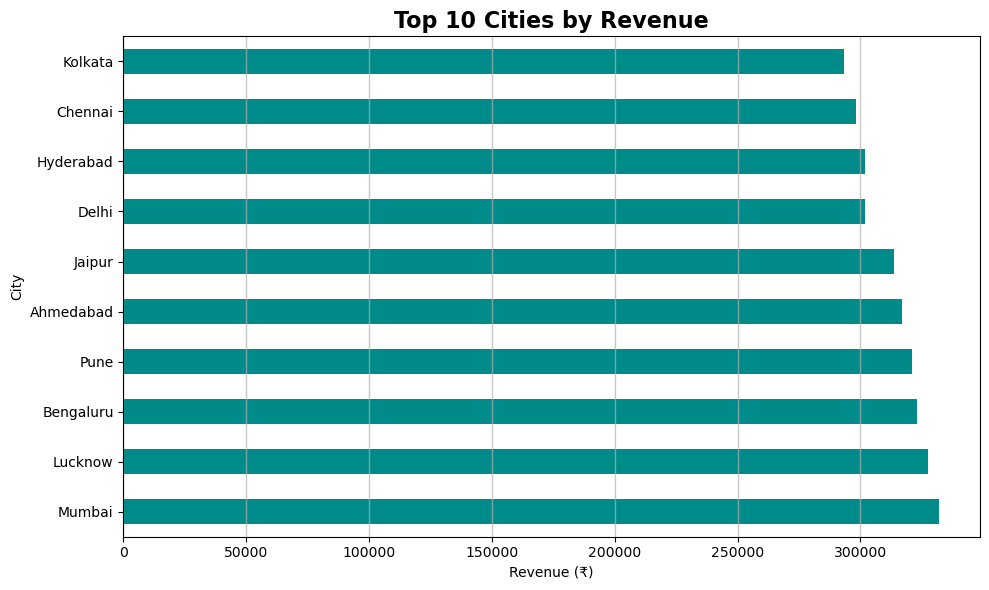

In [264]:
plt.figure(figsize=(10,6))

top_cities.plot(
    kind='barh',
    color='darkcyan'
)

plt.title('Top 10 Cities by Revenue',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Revenue (₹)')
plt.ylabel('City')

# Straight vertical grid lines
plt.grid(
    axis='x',
    linestyle='-',
    linewidth=1,
    alpha=0.7
)

plt.tight_layout()
plt.show()

### 2. Profit by Category (Bar Chart)
* Business Question: Which categories make the most money?


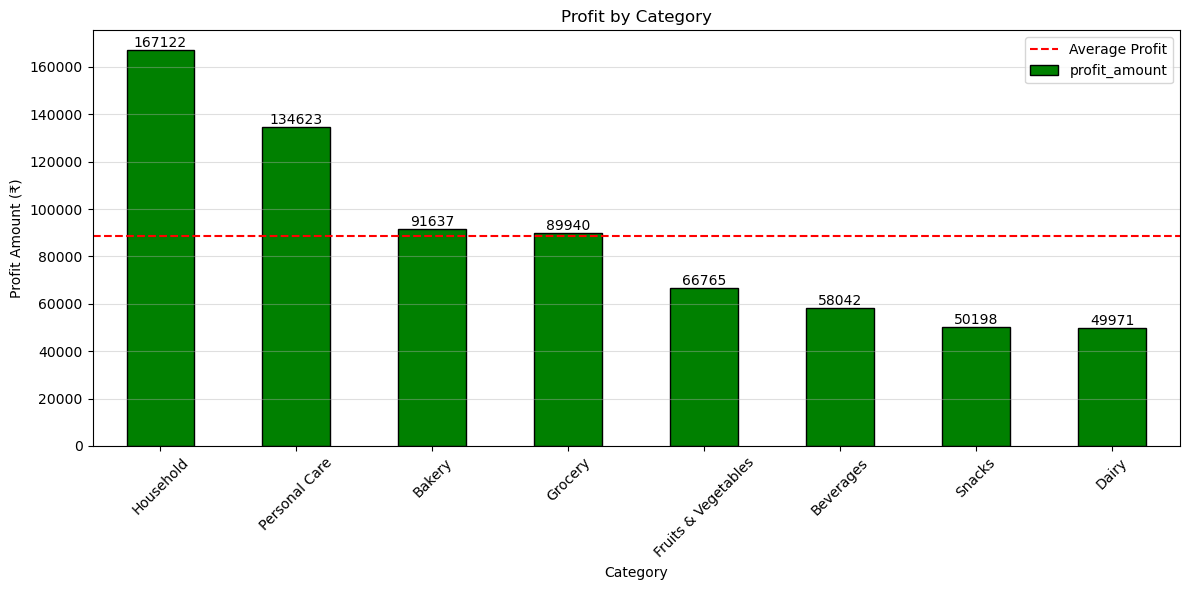

In [272]:
category_profit = (
    data.groupby('category')['profit_amount']
    .sum()
    .sort_values(ascending=False)
)

ax = category_profit.plot(
    kind='bar',
    figsize=(12,6),
    color='green',
    edgecolor='black'
)

ax.bar_label(ax.containers[0], fmt='%.0f')

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit Amount (₹)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.4)
plt.axhline(category_profit.mean(), color='red', ls='--', label='Average Profit')
plt.legend()
plt.tight_layout()
plt.show()

####  3.   Which product categories generate the highest revenue and profit, and how do categories compare in terms of overall business performance?


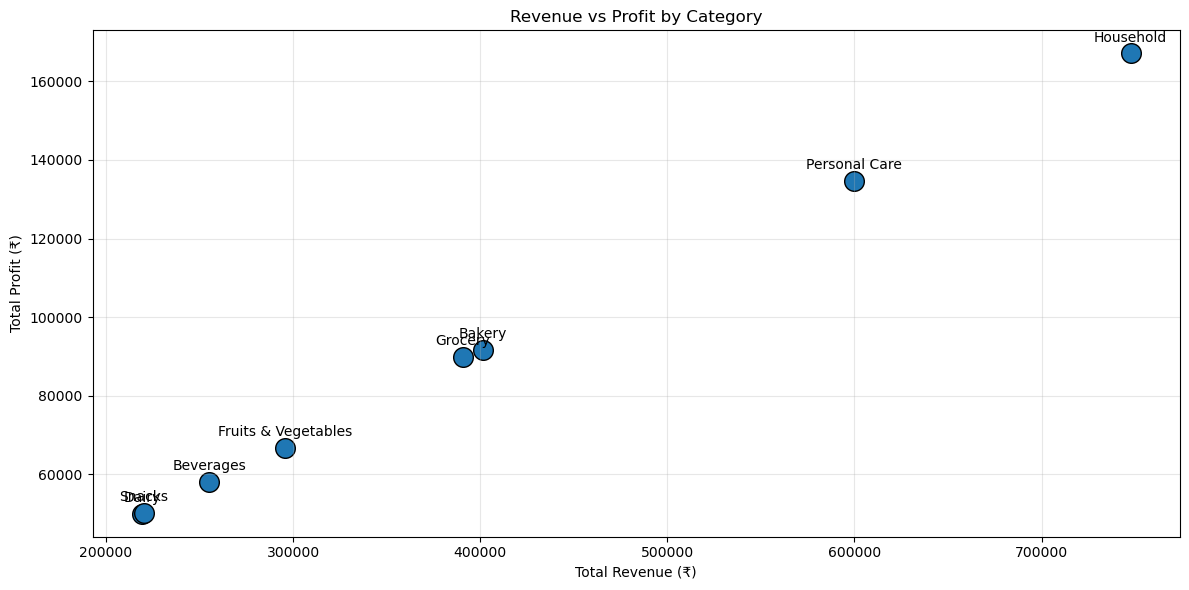

In [350]:
plt.figure(figsize=(12, 6))

plt.scatter(
    category_analysis['Revenue'],
    category_analysis['Profit'],
    s=200,
    edgecolor='black'
)

for _, row in category_analysis.iterrows():
    plt.text(
        row['Revenue'],
        row['Profit'] + 3000,  # label above dot
        row['category'],
        ha='center',
        fontsize=10
    )

plt.title('Revenue vs Profit by Category')
plt.xlabel('Total Revenue (₹)')
plt.ylabel('Total Profit (₹)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4. Delivery Performance by City

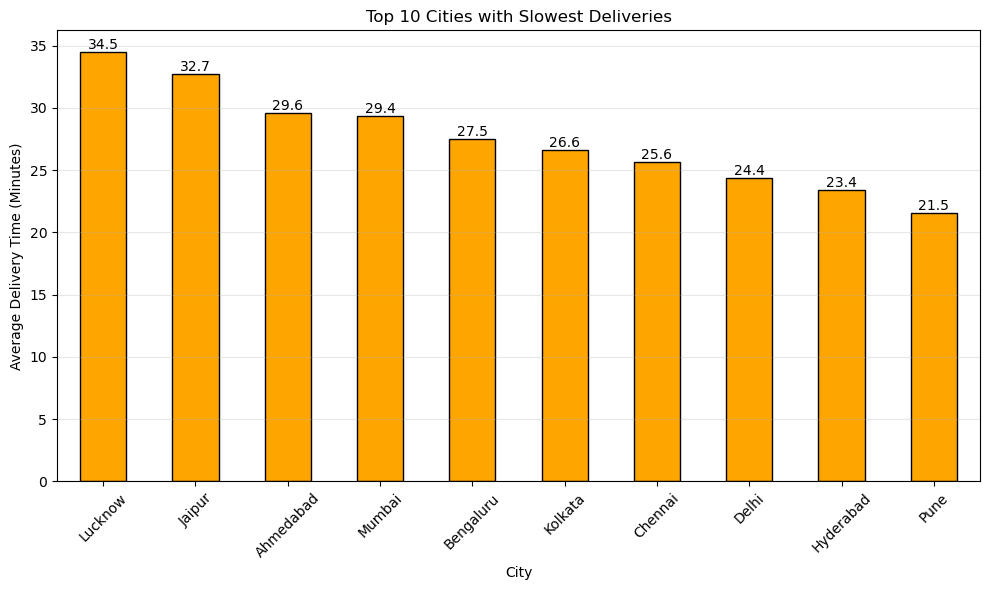

In [291]:
ax = (
    data.groupby('city')['delivery_time_min']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .plot(
        kind='bar',
        figsize=(10,6),
        color='orange',
        edgecolor='black'
    )
)

ax.bar_label(ax.containers[0], fmt='%.1f')

plt.title('Top 10 Cities with Slowest Deliveries')
plt.xlabel('City')
plt.ylabel('Average Delivery Time (Minutes)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 5. Discount vs Quantity Sold (Scatter Plot)

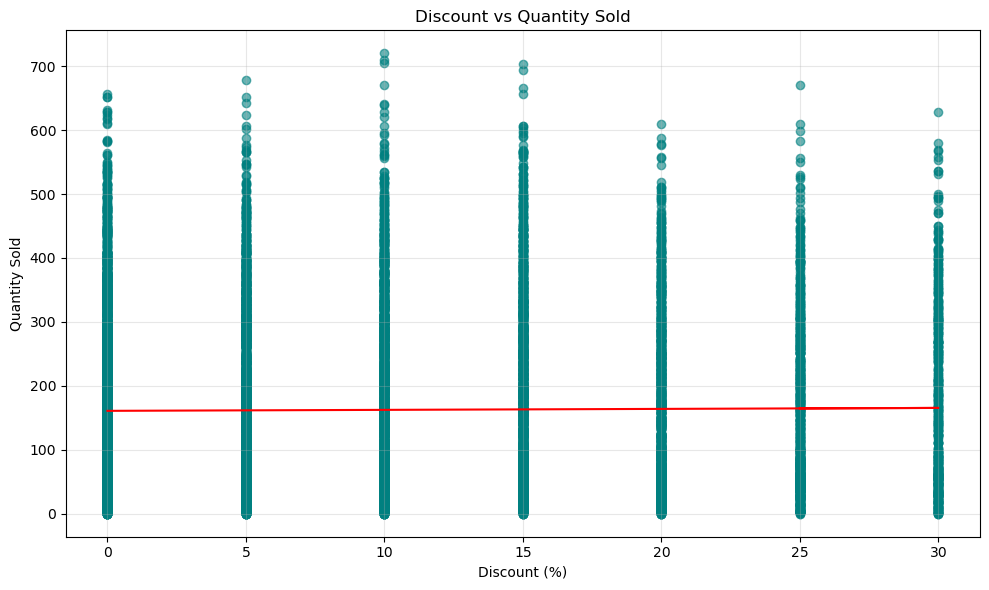

In [302]:
plt.figure(figsize=(10,6))

plt.scatter(
    data['discount_pct'],
    data['sold_quantity'],
    color='teal',
    alpha=0.6
)

z = np.polyfit(
    data['discount_pct'],
    data['sold_quantity'],
    1
)

plt.plot(
    data['discount_pct'],
    np.poly1d(z)(data['discount_pct']),
    color='red'
)

plt.title('Discount vs Quantity Sold')
plt.xlabel('Discount (%)')
plt.ylabel('Quantity Sold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6. Monthly Revenue Trend (Line Chart)

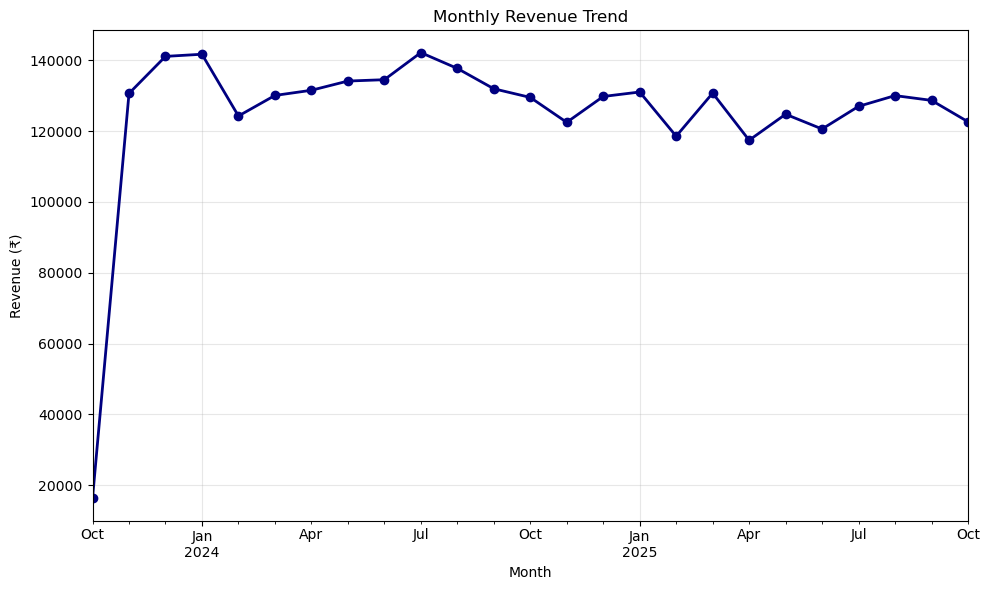

In [309]:

data['date_added'] = pd.to_datetime(data['date_added'])

monthly_rev = (
    data.groupby(data['date_added'].dt.to_period('M'))
    ['final_price']
    .sum()
)

ax = monthly_rev.plot(
    kind='line',
    figsize=(10,6),
    color='navy',
    marker='o',
    linewidth=2
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7 Revenue Share by Brand
* Business Question:
1. Which brands contribute the largest percentage of sales revenue?


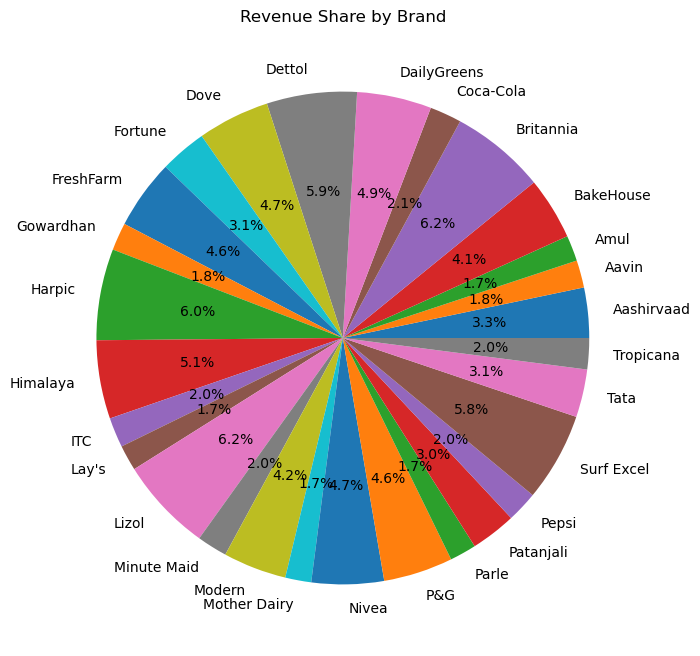

In [315]:
brand_rev = (
    data.groupby('brand')['final_price']
    .sum()
    .reset_index()
)

plt.figure(figsize=(8,8))
plt.pie(
    brand_rev['final_price'],
    labels=brand_rev['brand'],
    autopct='%1.1f%%'
)

plt.title('Revenue Share by Brand')
plt.show()

### 8. Orders Distribution by City
* Business Question:
1. Which cities account for the highest proportion of orders?

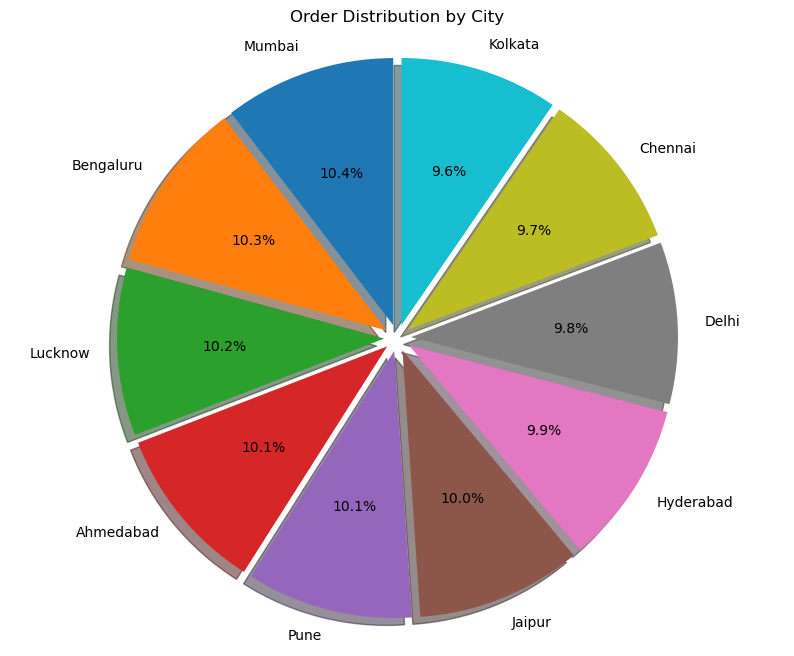

In [325]:
city_orders = (
    data['city']
    .value_counts()
    .reset_index()
)

city_orders.columns = ['city', 'orders']

plt.figure(figsize=(10,8))

plt.pie(
    city_orders['orders'],
    labels=city_orders['city'],
    autopct='%1.1f%%',
    shadow=True,          # 3D-like effect
    startangle=90,
    explode=[0.05]*len(city_orders)
)

plt.title('Order Distribution by City')
plt.axis('equal')

plt.show()

### 9 Compare profit distributions across categories to identify the most profitable and stable categories.

<Figure size 1200x600 with 0 Axes>

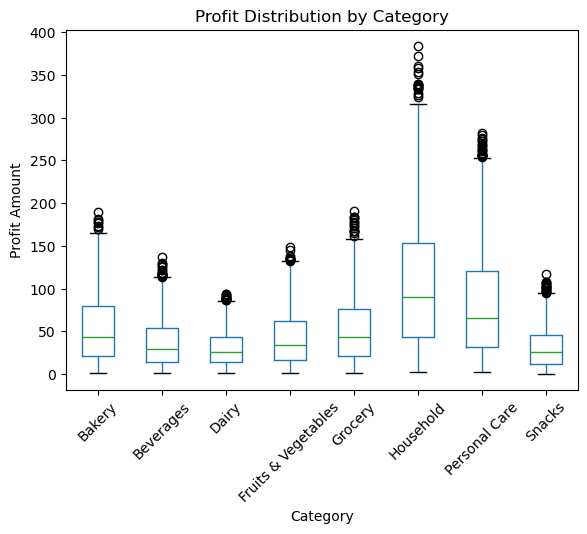

In [327]:
plt.figure(figsize=(12,6))

data.boxplot(
    column='profit_amount',
    by='category',
    rot=45,
    grid=False
)

plt.title('Profit Distribution by Category')
plt.suptitle('')
plt.xlabel('Category')
plt.ylabel('Profit Amount')

plt.show()

 ### 10.Which product categories generate high revenue but are receiving high discounts?

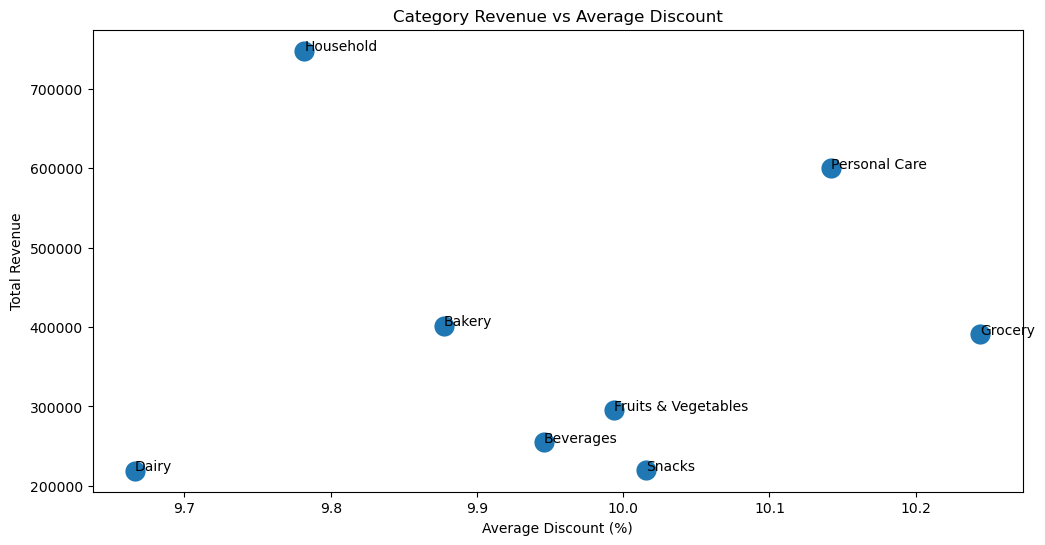

In [382]:

category_analysis = (
    data.groupby('category')
    .agg({
        'final_price':'sum',
        'discount_pct':'mean'
    })
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=category_analysis,
    x='discount_pct',
    y='final_price',
    s=250
)

for _, row in category_analysis.iterrows():
    plt.text(
        row['discount_pct'],
        row['final_price'],
        row['category'],
        fontsize=10
    )

plt.title('Category Revenue vs Average Discount')
plt.xlabel('Average Discount (%)')
plt.ylabel('Total Revenue')
plt.show()

# 📈 Executive Summary

The analysis identified key revenue-driving categories, profitable products, customer purchasing patterns, discount impacts, and operational opportunities.

# 🔍 Key Business Insights

1. Top categories contribute a significant share of total revenue.
2. Some heavily discounted products generate lower profit margins.
3. High-performing cities drive a large percentage of order volume.
4. Delivery performance varies across locations.
5. Revenue and profit are concentrated among selected categories and brands.

# 🚀 Recommendations

- Increase inventory for high-demand products.
- Optimize discount strategies to protect profit margins.
- Focus marketing on high-profit categories.
- Improve delivery performance in slower regions.
- Monitor inventory nearing expiry dates.
- Track category-level KPIs regularly.
